In [1]:
import gc

In [2]:
# showing table schema and creating path variables
import duckdb

# PARQUET FILES ARE FROM https://huggingface.co/datasets/SII-WANGZJ/Polymarket_data BIG THANK YOU FOR ALL THE DATA
# Note I made a new User file to add if a users trade won or not in DBshenanigans.py to make everything easier for training (the win rate is about 49.91%)

tradesPQ = 'X:/PolymarketData/trades.parquet'
marketPQ = 'X:/PolymarketData/markets.parquet'
usersPQ = 'X:/PolymarketData/Users2.parquet'
print("User Schema:")
print(duckdb.query(f" SELECT * FROM '{usersPQ}' LIMIT 1"))
print("Trade Schema:")
print(duckdb.query(f" SELECT * FROM '{tradesPQ}' LIMIT 1"))
print("Market Schema:")
print(duckdb.query(f" SELECT * FROM '{marketPQ}' LIMIT 1"))

User Schema:
┌────────────┬──────────────┬──────────────────────────────────────────────────────────────────┬───────────┬────────────────────────────────────────────┬─────────┬───────────┬────────────┬──────────────┬────────┬───────────┬────────────────────────────────────────────────────────────────────┬──────────┬──────────────┬─────────┐
│ timestamp  │ block_number │                         transaction_hash                         │ log_index │                  address                   │  role   │ direction │ usd_amount │ token_amount │ price  │ market_id │                            condition_id                            │ event_id │ nonusdc_side │   won   │
│   uint64   │    uint64    │                             varchar                              │  uint32   │                  varchar                   │ varchar │  varchar  │   double   │    double    │ double │  varchar  │                              varchar                               │ varchar  │   varchar    │ boolean

In [3]:
userdf = duckdb.query(f"SELECT address, COUNT(*) AS nTrades, AVG(CAST(won AS INTEGER)) AS win_rate, AVG(usd_amount) as avg_spent, SUM(usd_amount) as total_spent, STDDEV(price) as std_price, AVG(price) as avg_price FROM '{usersPQ}' GROUP BY address HAVING COUNT(*) > 20 LIMIT 20000").to_df()


<Axes: >

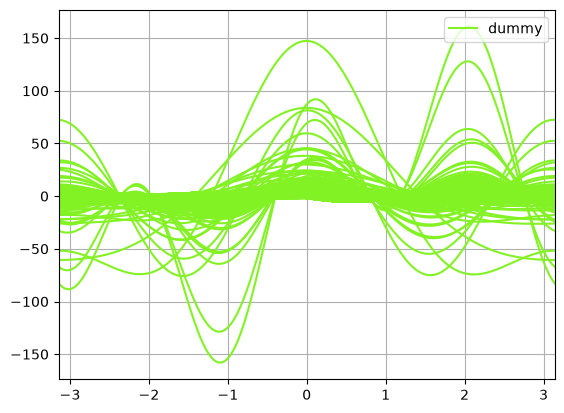

In [6]:
import pandas as pd

rest = userdf.columns.difference(["address","dummy"])
normdf = (userdf[rest] - userdf[rest].mean())/userdf[rest].std()
normdf["dummy"] = "dummy"
pd.plotting.andrews_curves(normdf, 'dummy', samples=200)

In [23]:

from sklearn.cluster import DBSCAN

clustering = DBSCAN(eps=0.25, min_samples=5).fit_predict(normdf[rest])
del normdf
gc.collect()
userdf['category'] = pd.Series(clustering, index=userdf.index)

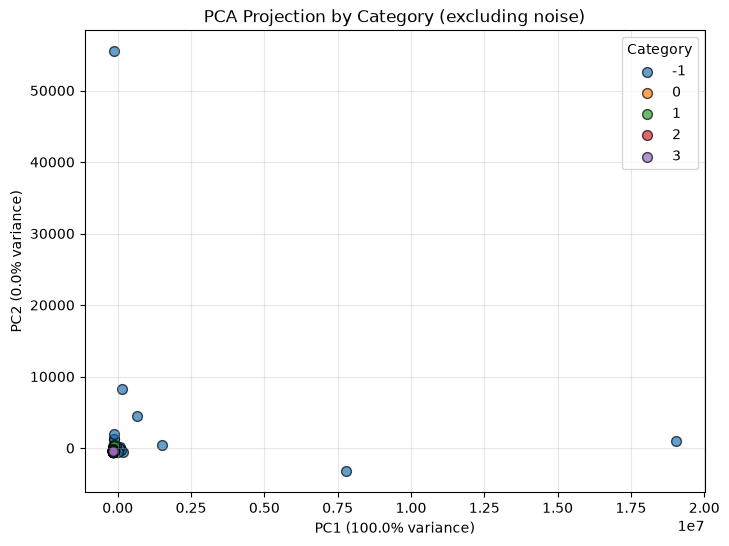

In [24]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
np.random.seed(42)

pca = PCA(n_components=2)
transformed_data = pca.fit_transform(userdf[rest])  

mask_valid = ~userdf['category'].isin([-42])
labels_filtered = userdf.loc[mask_valid, 'category'].values
data_filtered = transformed_data[mask_valid.values]

unique_labels = np.unique(labels_filtered)

plt.figure(figsize=(8, 6))
for label in unique_labels:
    mask = labels_filtered == label
    plt.scatter(
        data_filtered[mask, 0],
        data_filtered[mask, 1],
        label=str(label),
        alpha=0.7,
        edgecolor='k',
        s=50
    )

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA Projection by Category (excluding noise)")
plt.legend(title="Category")
plt.grid(True, alpha=0.3)
plt.show()

<Axes: >

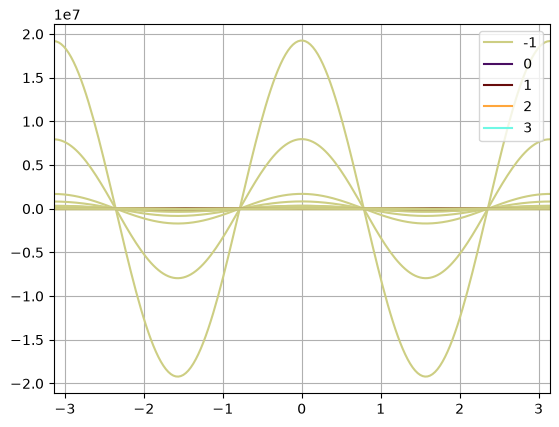

In [25]:
filtered_df = userdf[~userdf['category'].isin([-42])]
pd.plotting.andrews_curves(filtered_df[filtered_df.columns.difference(["address","dummy"])], 'category', samples=200)

In [26]:
print (userdf.category.value_counts())
sampledf = userdf.drop_duplicates(subset=['category'])
print(sampledf)

category
-1    158
 1     16
 0     11
 2     10
 3      5
Name: count, dtype: int64
                                       address  nTrades  win_rate   avg_spent  \
0   0x7c61fa02f1fdb9bcf5e5c904ca6a724abc0315c0     1085  0.695853  214.671982   
20  0x1cefcc21bcef48eba67cfa95658920e18bfef51a       72  0.722222    4.028194   
22  0x57f9e2814acc35671964c64b966afce67ea47cbd       36  0.972222   43.391667   
59  0xebf9fa7d59b18fdc36d2732eb82bedbc9130d071       47  0.765957    6.797872   
98  0x296e357875d2ab8d0bc0068449521c4ef8ced5c5      172  0.389535   32.871047   

      total_spent  std_price  avg_price  category  
0   232919.100962   0.246811   0.665988        -1  
20     290.030000   0.417447   0.666396         0  
22    1562.100000   0.067353   0.946963         1  
59     319.500000   0.279806   0.808362         2  
98    5653.820000   0.457398   0.395566         3  


In [27]:
for column in rest:
    print(column)
    print("-"*20)
    print(userdf.groupby("category")[column].describe())

avg_price
--------------------
          count      mean       std       min       25%       50%       75%  \
category                                                                      
-1        158.0  0.552511  0.264659  0.017606  0.325292  0.537012  0.779293   
 0         11.0  0.684277  0.025193  0.631815  0.668266  0.690932  0.703697   
 1         16.0  0.980447  0.011865  0.946963  0.978455  0.980895  0.987401   
 2         10.0  0.805846  0.021783  0.761058  0.808829  0.811780  0.813540   
 3          5.0  0.370942  0.042737  0.302455  0.355692  0.395566  0.396672   

               max  
category            
-1        0.996293  
 0        0.713773  
 1        0.995674  
 2        0.835667  
 3        0.404323  
avg_spent
--------------------
          count        mean         std        min        25%        50%  \
category                                                                   
-1        158.0  134.866453  180.385667   0.025909  16.059806  58.962757   
 0       